# tableros bien horizontales

In [9]:
import cv2
import matplotlib.pyplot as plt

¡Éxito! Se detectó el recuadro exterior del tablero.


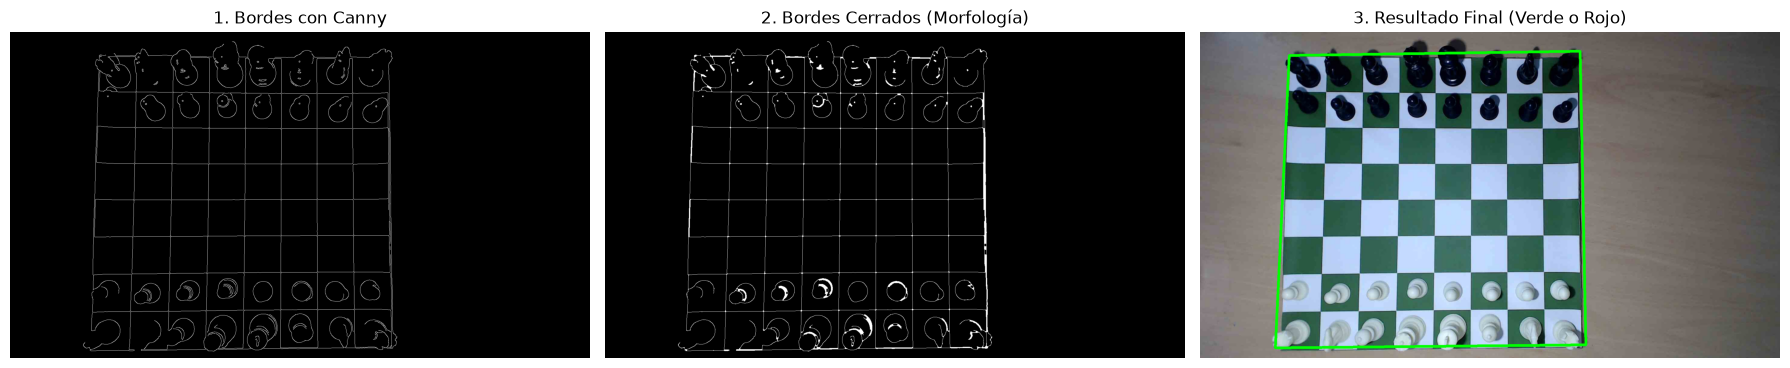

In [10]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# 1. Cargar la imagen
ruta = "../../data/raw/tablero_vertical.jpg"
imagen_gris = cv2.imread(ruta, 0)
imagen_color = cv2.imread(ruta)
imagen_color = cv2.cvtColor(imagen_color, cv2.COLOR_BGR2RGB)

if imagen_gris is None:
    print("No se pudo cargar la imagen. Revisa la ruta.")
else:
    # 2. SUAVIZADO: Eliminamos imperfecciones o texturas sutiles
    desenfocado = cv2.GaussianBlur(imagen_gris, (5, 5), 0)
    
    # 3. CANNY (REALCE DE BORDES): Busca cambios bruscos de intensidad.
    # Los valores 50 y 150 son los umbrales de sensibilidad.
    bordes_canny = cv2.Canny(desenfocado, 50, 150)
    
    # 4. OPERACIÓN MORFOLÓGICA (CIERRE): Creamos un "bloque" de 5x5 píxeles
    # para conectar líneas del borde exterior que hayan quedado separadas o rotas.
    kernel = np.ones((5, 5), np.uint8)
    bordes_cerrados = cv2.morphologyEx(bordes_canny, cv2.MORPH_CLOSE, kernel)
    
    # 5. ENCONTRAR CONTORNOS: Buscamos solo el contorno más externo
    contornos, _ = cv2.findContours(bordes_cerrados, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    
    # Ordenamos por tamaño (área) de mayor a menor
    contornos = sorted(contornos, key=cv2.contourArea, reverse=True)
    
    tablero_esquinas = None
    
    # 6. FILTRAR POR RECTÁNGULO: Buscamos cuál de los contornos grandes tiene 4 esquinas
    for c in contornos:
        perimetro = cv2.arcLength(c, True)
        aproximacion = cv2.approxPolyDP(c, 0.02 * perimetro, True)
        
        if len(aproximacion) == 4:
            tablero_esquinas = aproximacion
            break
            
    # 7. DIBUJAR Y MOSTRAR TODO EL PROCESO
    if tablero_esquinas is not None:
        print("¡Éxito! Se detectó el recuadro exterior del tablero.")
        cv2.drawContours(imagen_color, [tablero_esquinas], -1, (0, 255, 0), 7)
    else:
        print("No se encontró un contorno exterior de 4 esquinas perfecto.")
        print("Intentaremos dibujar el contorno más grande que encontró (tenga o no 4 esquinas) para ver qué pasó:")
        if len(contornos) > 0:
            cv2.drawContours(imagen_color, [contornos[0]], -1, (255, 0, 0), 5)

    # Bloque de visualización en Jupyter para diagnóstico
    fig, axs = plt.subplots(1, 3, figsize=(18, 6))
    
    axs[0].imshow(bordes_canny, cmap='gray')
    axs[0].set_title("1. Bordes con Canny")
    axs[0].axis('off')
    
    axs[1].imshow(bordes_cerrados, cmap='gray')
    axs[1].set_title("2. Bordes Cerrados (Morfología)")
    axs[1].axis('off')
    
    axs[2].imshow(imagen_color)
    axs[2].set_title("3. Resultado Final (Verde o Rojo)")
    axs[2].axis('off')
    
    plt.tight_layout()
    plt.show()


In [11]:
print(tablero_esquinas)

[[[ 295   78]]

 [[ 249 1046]]

 [[1277 1036]]

 [[1258   64]]]


Una vez delimitado el tablero podemos identificar las zonas en una matriz!!!

Aunque el tablero puede estar horizontal o vertical y las negras pueden estar arriba o abajo, para eso vamos a detectar

# identificar negras y blancas

ya tenemos el ancho

Voy a identificar las posiciones del tablero de las imagenes para saber como se van actualizando las posiciones.

sacamos los minimos de de cada axis.

Límites calculados:
X mín (Izquierda): 249 | X máx (Derecha): 1277
Y mín (Superior): 64  | Y máx (Inferior): 1046


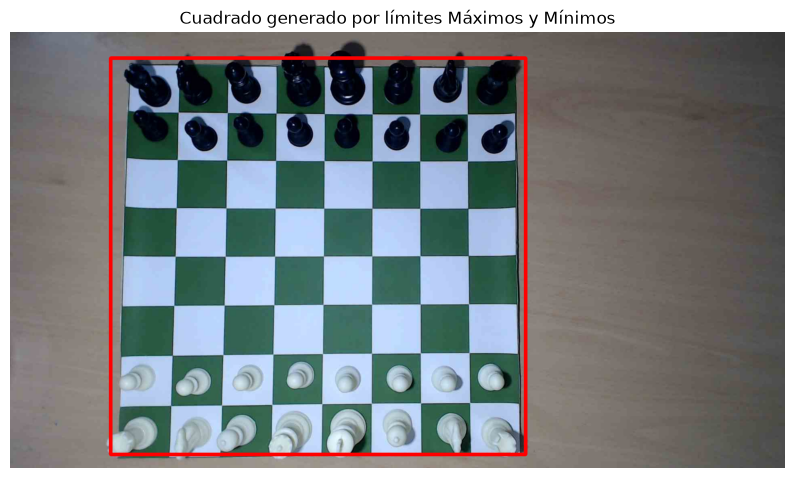

In [13]:

imagen_color = cv2.imread(ruta)
imagen_color = cv2.cvtColor(imagen_color, cv2.COLOR_BGR2RGB)

if imagen_color is None:
    print("No se pudo cargar la imagen. Revisa la ruta.")
else:
    # 2. TUS PUNTOS ACTUALES
    #tablero_esquinas = np.array([[[295, 78]], [[249, 1046]], [[1277, 1036]], [[1258, 64]]])

    # Reshape para trabajar cómodamente con un array de (4, 2)
    puntos = tablero_esquinas.reshape(4, 2)

    # 3. EXTRAER MÍNIMOS Y MÁXIMOS DE CADA EJE
    # puntos[:, 0] hace referencia a todas las X
    # puntos[:, 1] hace referencia a todas las Y
    x_min = int(np.min(puntos[:, 0]))
    x_max = int(np.max(puntos[:, 0]))
    y_min = int(np.min(puntos[:, 1]))
    y_max = int(np.max(puntos[:, 1]))

    print(f"Límites calculados:")
    print(f"X mín (Izquierda): {x_min} | X máx (Derecha): {x_max}")
    print(f"Y mín (Superior): {y_min}  | Y máx (Inferior): {y_max}")

    # 4. DIBUJAR EL RECTÁNGULO EN LA IMAGEN
    # cv2.rectangle necesita la esquina superior izquierda (x_min, y_min) 
    # y la esquina inferior derecha (x_max, y_max)
    cv2.rectangle(imagen_color, (x_min, y_min), (x_max, y_max), (255, 0, 0), 7) # Rectángulo Azul, grosor 7

    # 5. MOSTRAR LA IMAGEN CON EL RECTÁNGULO
    plt.figure(figsize=(10, 10))
    plt.imshow(imagen_color)
    plt.title("Cuadrado generado por límites Máximos y Mínimos")
    plt.axis('off')
    plt.show()

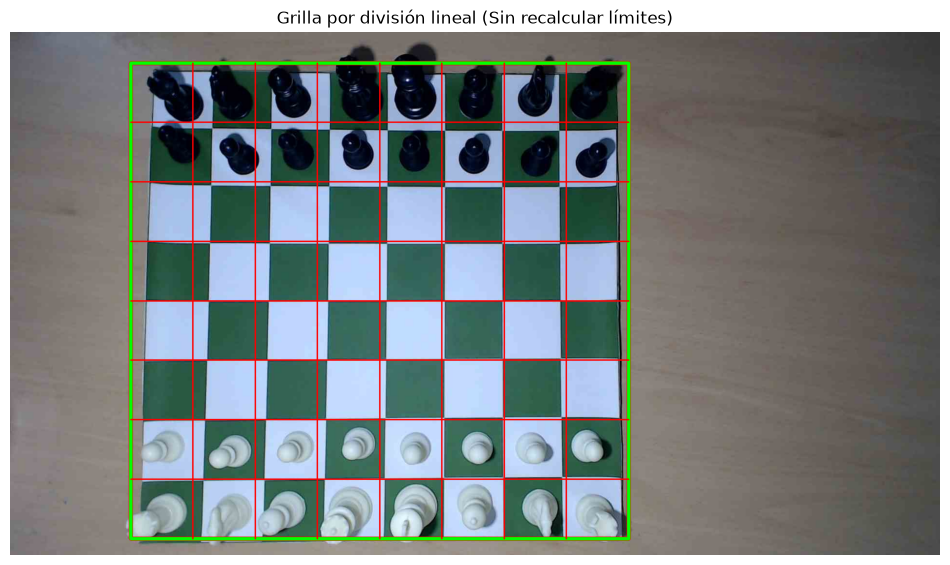

In [14]:
# 1. Calcular el tamaño de cada celda con las variables que ya tienes
ancho_total = x_max - x_min
alto_total = y_max - y_min

celda_ancho = ancho_total / 8
celda_alto = alto_total / 8

# 2. Dibujar el rectángulo contenedor exterior (Verde)
cv2.rectangle(imagen_color, (x_min, y_min), (x_max, y_max), (0, 255, 0), 5)

# 3. Dibujar las líneas de la grilla usando los límites existentes (Azul)
for i in range(1, 8):
    # Líneas Verticales
    x_linea = int(x_min + (i * celda_ancho))
    cv2.line(imagen_color, (x_linea, y_min), (x_linea, y_max), (255, 0, 0), 2)

    # Líneas Horizontales
    y_linea = int(y_min + (i * celda_alto))
    cv2.line(imagen_color, (x_min, y_linea), (x_max, y_linea), (255, 0, 0), 2)

# 4. Mostrar el resultado en Jupyter
plt.figure(figsize=(12, 12))
plt.imshow(imagen_color)
plt.title("Grilla por división lineal (Sin recalcular límites)")
plt.axis('off')
plt.show()

# corrigiendo la perspectiva

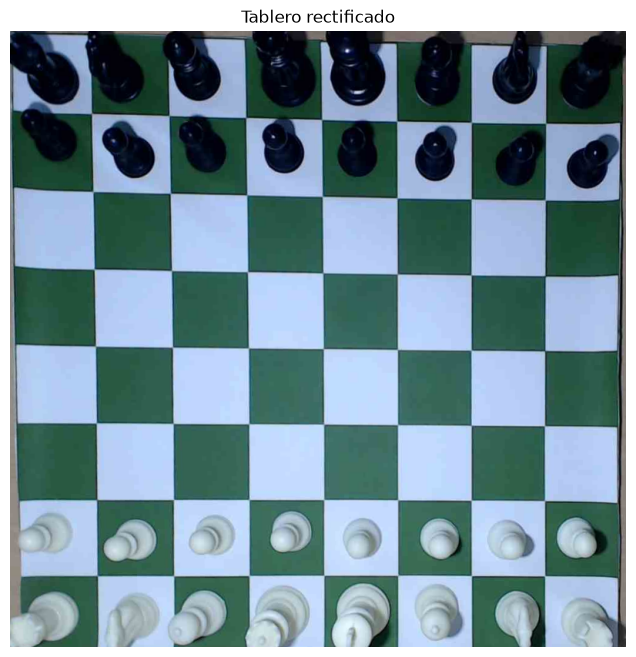

In [18]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

# Cargar imagen
imagen = cv2.imread(ruta)
imagen = cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB)

# Esquinas detectadas del tablero
# Deben estar en orden:
# superior izquierda, inferior izquierda,
# inferior derecha, superior derecha

pts_origen = np.array([
    [295, 78],      # superior izquierda
    [249, 1046],    # inferior izquierda
    [1277, 1036],   # inferior derecha
    [1258, 64]      # superior derecha
], dtype=np.float32)

# Tamaño deseado para el tablero corregido
lado = 800

pts_destino = np.array([
    [0, 0],
    [0, lado],
    [lado, lado],
    [lado, 0]
], dtype=np.float32)

# Matriz de homografía
H = cv2.getPerspectiveTransform(pts_origen, pts_destino)

# Corregir perspectiva
tablero_rectificado = cv2.warpPerspective(
    imagen,
    H,
    (lado, lado)
)

plt.figure(figsize=(8,8))
plt.imshow(tablero_rectificado)
plt.title("Tablero rectificado")
plt.axis("off")
plt.show()

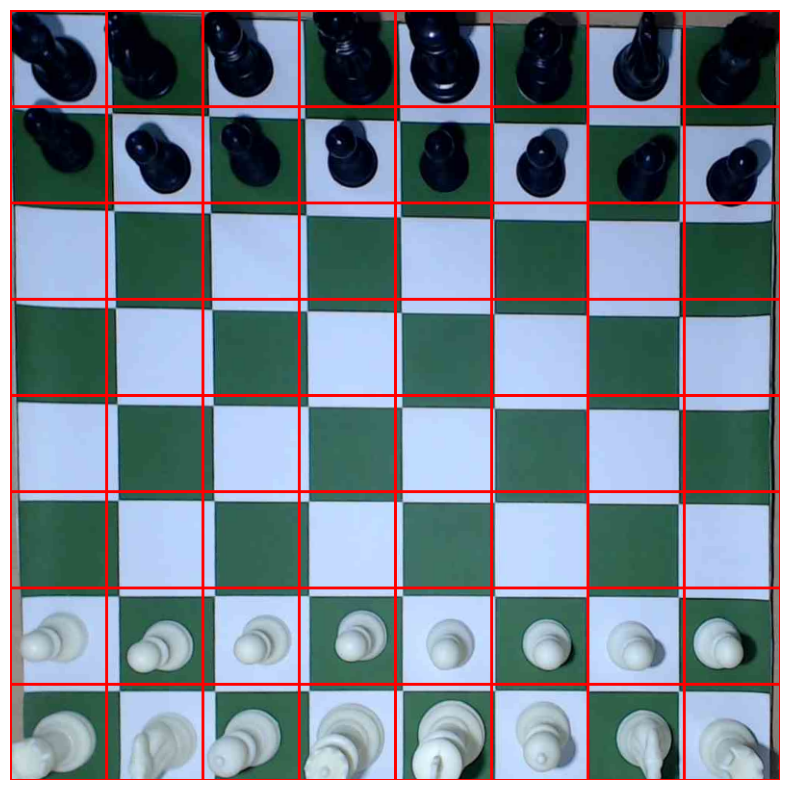

In [ ]:
img = tablero_rectificado.copy()



lado = img.shape[0]
tam_celda = lado / 8

for fila in range(8):
    for columna in range(8):

        x1 = int(columna * tam_celda)
        y1 = int(fila * tam_celda)

        x2 = int((columna + 1) * tam_celda)
        y2 = int((fila + 1) * tam_celda)

        cv2.rectangle(
            img,
            (x1, y1),
            (x2, y2),
            (255, 0, 0),
            2
        )
        

plt.figure(figsize=(10,10))
plt.imshow(img)
plt.axis("off")
plt.show()

Una vez obtenida la imagen, vamos a analizar donde se encuentran las negras y las blancas

In [21]:
matriz = np.zeros(shape=(8,8))
print(matriz)

x_inf = np.min(tablero_esquinas[:])

[[0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0. 0. 0. 0.]]
